# Template - 3D Sound rendering Lab

### G. Richard, Feb. 2026

In [1]:
import os, sys, wave, struct

import numpy as np
from scipy.io import loadmat
import pyaudio
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from math import ceil
from IPython.display import Audio

In [2]:
def load_music(file):
    return wave.open(file, 'rb')


def play_music(file, chunk = 1024):
    """
    Script from PyAudio doc
    """
    wf = load_music(file)
    p = pyaudio.PyAudio()
    stream = p.open(format=p.get_format_from_width(wf.getsampwidth()),
                    channels=wf.getnchannels(),
                    rate=wf.getframerate(),
                    output=True)
    data = wf.readframes(chunk)

    while data:
        stream.write(data)
        data = wf.readframes(chunk )

    stream.stop_stream()
    stream.close()
    p.terminate()
    
    
def plot_sound(data, times, name='default_name', save=False):
    plt.figure(figsize=(30, 4))
    plt.fill_between(times, data)
    plt.xlim(times[0], times[-1])
    plt.xlabel('time (s)')
    plt.ylabel('amplitude')
    if save:
        plt.savefig(name+'.png', dpi=100)
    plt.show()
    

def nextpow2(x):
    assert x>0
    p = ceil(np.log2(x))
    x_ = 2**p
    assert 2**(p-1) < x <= x_
    return p, x_



##  Reading and playing .wav file

Choose the name of music for the rest of the notebook. Sounds are assumed to be set in a folder named 'Sons' (same directory as notebook).

In [3]:
current_path = os.getcwd()
data_path = os.path.join(current_path, 'Sons')
filename = 'snare2_44.wav'
music = os.path.join(data_path, filename) 

### **Using wave**

In [4]:
wavefile = load_music(music)
print(wavefile.getparams())
fs = wavefile.getframerate()

_wave_params(nchannels=1, sampwidth=2, framerate=44100, nframes=16288, comptype='NONE', compname='not compressed')


In [5]:
play = True
if play :
    play_music(music) 

In [6]:
Fs = int(wavefile.getframerate())
num_samples = int(wavefile.getnframes())
data = wavefile.readframes(num_samples)
data = struct.unpack('{n}h'.format(n=num_samples), data)
x = np.array(data)

In [7]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

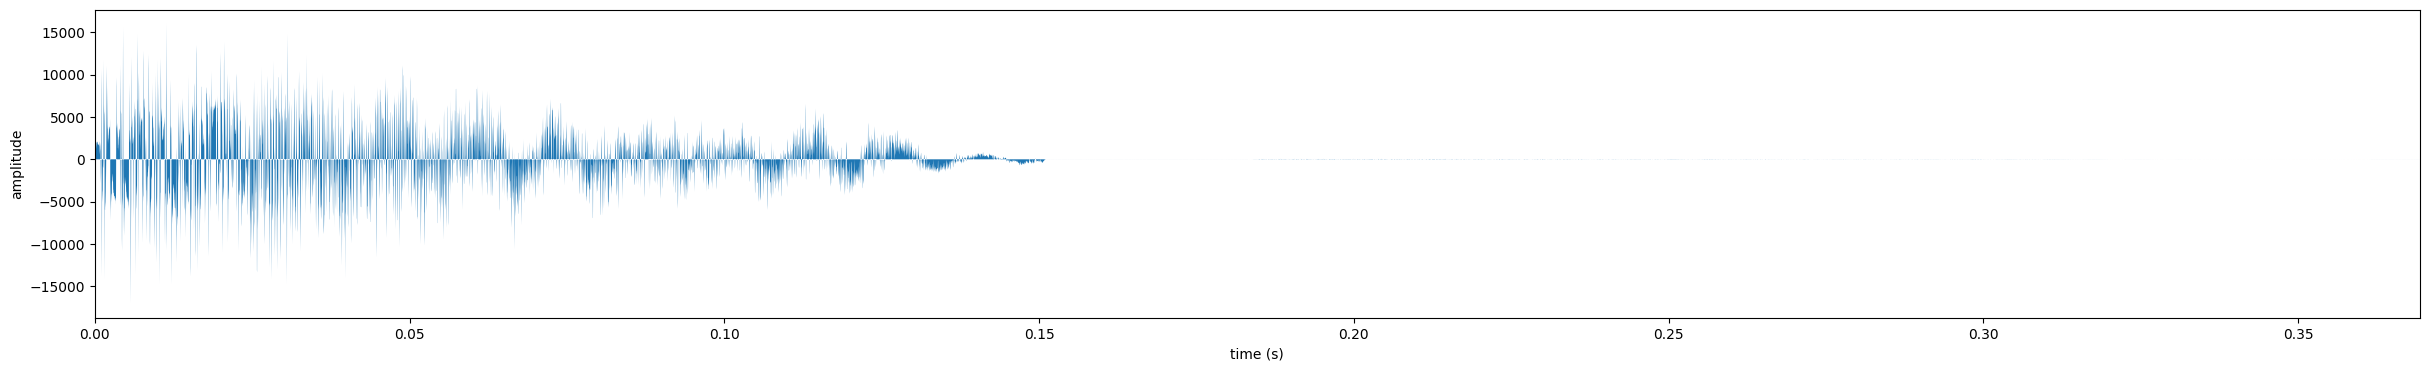

In [8]:
#plot_sound(x, times)
plot_sound(x,times)

##  Load subject HRTF

In [9]:
subject3 = loadmat('subject_003/hrir_final.mat')
subject44 = loadmat('subject_044/hrir_final.mat')
subject65 = loadmat('subject_065/hrir_final.mat')
subject165 = loadmat('subject_165/hrir_final.mat')


In [10]:
SUBJECT = subject165

## Problem 1: Binaural filtering

### Get the neareast HRTF given a position in space

In [11]:
def getNearestUCDpulse(azimuth, elevation, subject):
    
    elmax = 49
    elindices = np.arange(elmax+1)
    elevations = -45 + 5.625*(elindices)
    azimuths = np.hstack([[-80, -65, -55],np.arange(-45, 50, 5),[55, 65, 80]])
    
    el = round((elevation+45)/5.625)
    el = np.clip(el, 0, elmax)
    elerr = el - ((elevation+45)/5.625)
    
    azim = np.argmin(np.abs(azimuths - azimuth))
    azerr = np.min(np.abs(azimuths - azimuth))
    
    print("Les parametres utilises pour la HRTF sont:")
    print("\t azimuths: {}".format(azimuths[azim]))
    print("\t elevation: {}".format(-45 + 5.625*el))
    
    print("\nLes indices sont:")
    print("\t azim: {}".format(azim))
    print("\t el: {}".format(el))
    
    pulse = np.vstack([subject['hrir_l'][azim, el], subject['hrir_r'][azim, el]])
    
    return pulse

### Binaural ﬁltering for a ﬁxed position in space

#### get the hrtf for the position : right in front at 1m (0, 0)

In [12]:
hrtf=getNearestUCDpulse(0, 0, SUBJECT)

Les parametres utilises pour la HRTF sont:
	 azimuths: 0
	 elevation: 0.0

Les indices sont:
	 azim: 12
	 el: 8


#### plot the hrtf for left ear

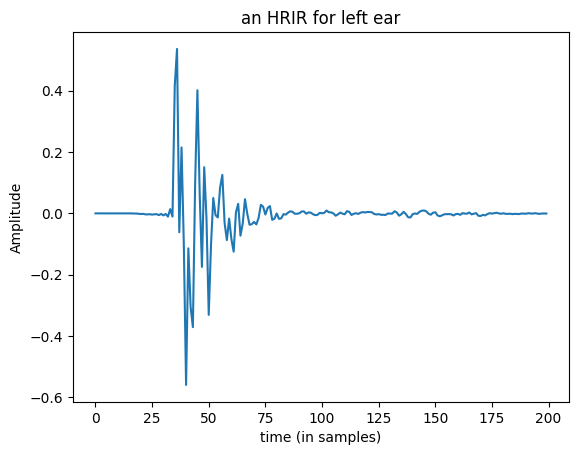

In [13]:
plt.plot(hrtf[0]);
plt.xlabel("time (in samples)")
plt.ylabel("Amplitude")
plt.title("an HRIR for left ear")

plt.show()

#### plot the hrtf for right ear

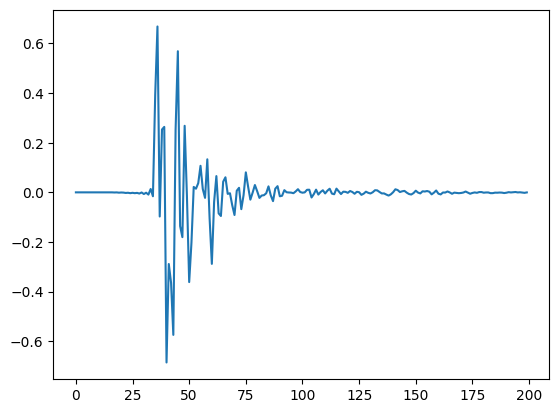

In [14]:
plt.plot(hrtf[1]);

In [15]:
def apply_filter(x, hrtf):
    """
    Apply the hrtf filter to the signal x.
    The hrtf is a 2xN array, where the first row is the left ear and the second row is the right ear.
    The output is a 2xM array, where the first row is yg (left) and the second row is yd (right).
    """
    yg = np.convolve(x, hrtf[0], mode='full')
    yd = np.convolve(x, hrtf[1], mode='full')
    return np.vstack([yg, yd])


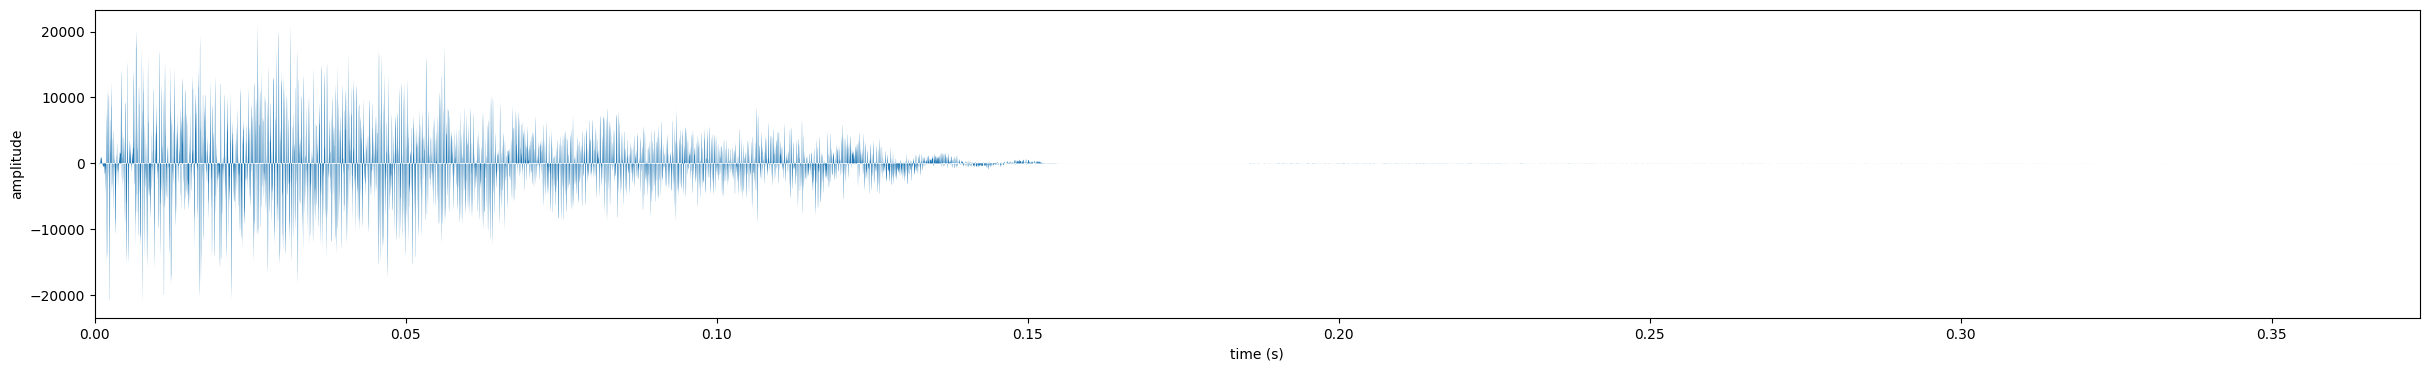

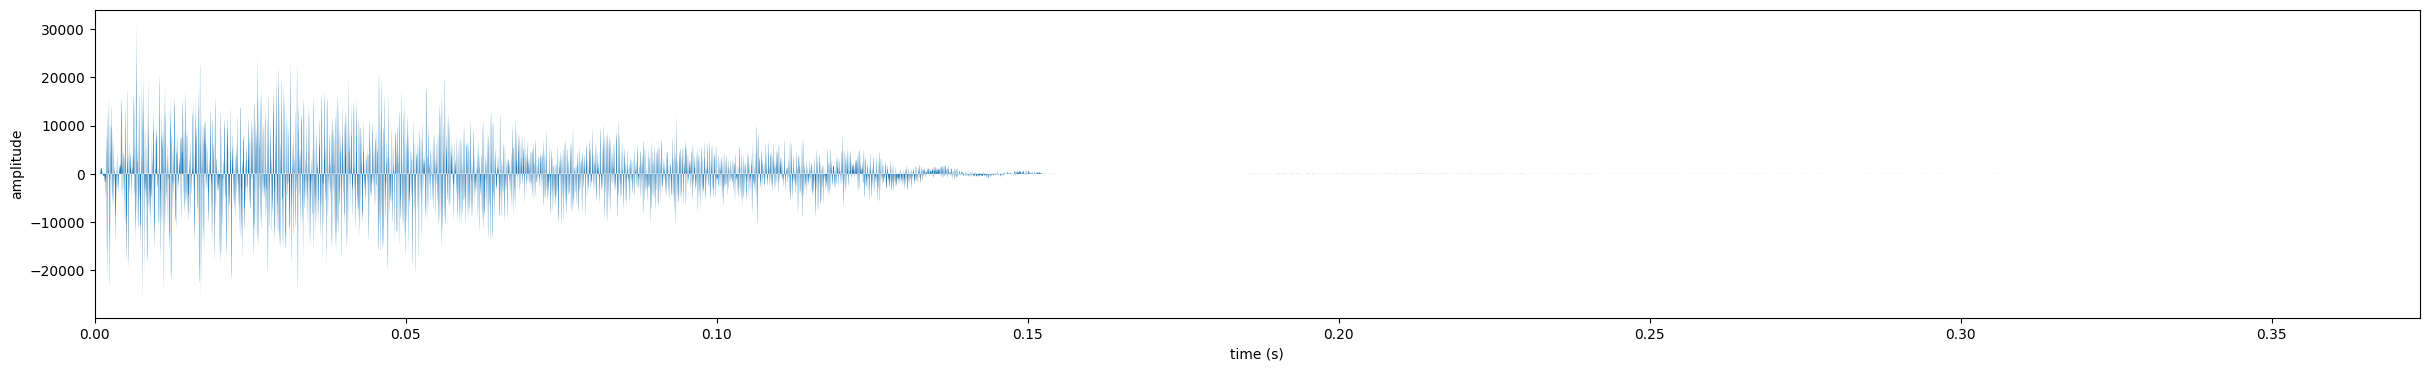

In [16]:
y = apply_filter(x, hrtf)
times = np.arange(y.shape[1])*timestep
plot_sound(y[0], times, name='filtered_left', save=True)
plot_sound(y[1], times, name='filtered_right', save=True)


In [17]:
#front
hrtf=getNearestUCDpulse(0, 0, SUBJECT)
y = apply_filter(x, hrtf)
Audio(y, rate=fs)

Les parametres utilises pour la HRTF sont:
	 azimuths: 0
	 elevation: 0.0

Les indices sont:
	 azim: 12
	 el: 8


In [18]:
#left
hrtf=getNearestUCDpulse(-90, 0, SUBJECT)
y = apply_filter(x, hrtf)
Audio(y, rate=fs)

Les parametres utilises pour la HRTF sont:
	 azimuths: -80
	 elevation: 0.0

Les indices sont:
	 azim: 0
	 el: 8


In [19]:
#right
hrtf=getNearestUCDpulse(90, 0, SUBJECT)
y = apply_filter(x, hrtf)
Audio(y, rate=fs)

Les parametres utilises pour la HRTF sont:
	 azimuths: 80
	 elevation: 0.0

Les indices sont:
	 azim: 24
	 el: 8


In [20]:
#up
hrtf=getNearestUCDpulse(0, 90, SUBJECT)
y = apply_filter(x, hrtf)
Audio(y, rate=fs)

Les parametres utilises pour la HRTF sont:
	 azimuths: 0
	 elevation: 90.0

Les indices sont:
	 azim: 12
	 el: 24


In [21]:
#behind
hrtf=getNearestUCDpulse(0, 180, SUBJECT)
y = apply_filter(x, hrtf)
Audio(y, rate=fs)

Les parametres utilises pour la HRTF sont:
	 azimuths: 0
	 elevation: 180.0

Les indices sont:
	 azim: 12
	 el: 40


#### Comment Karina
I can hear the left-right variations quite clearly, but I do not perseave the elevation variations. Subject 165 seems to fit me best.

#### Comment Yossri
It’s the same for me, but subject 44 suits me best.

### Binaural ﬁltering for a trajectory

In [22]:
# trajectory 1: short left/right azimuth sweep, 0° elevation
traj1 = []
for az in range(-90, 91, 15):
    traj1.append(getNearestUCDpulse(az, 0, subject44))

# trajectory 2:  0 azimuth, -45 - +230 elevation
traj2 = []
start = -45
while start <= 230:
    traj2.append(getNearestUCDpulse(0, start, subject44))
    start += 5.625 # 5.625 is the step between two elevations in the HRTF dataset
    
# trajectory 3: short diagonal zig-zag (3 diagonals, 6 points each)
traj3 = []
diagonal_segments = [
    ((-60, -30), (60, 10)),
    ((60, 10), (-60, 35)),
    ((-60, 35), (60, 55)),
]
n_points_per_segment = 6

for (az0, el0), (az1, el1) in diagonal_segments:
    for t in np.linspace(0, 1, n_points_per_segment):
        az = az0 + t * (az1 - az0)
        el = el0 + t * (el1 - el0)
        traj3.append(getNearestUCDpulse(float(az), float(el), subject44))



Les parametres utilises pour la HRTF sont:
	 azimuths: -80
	 elevation: 0.0

Les indices sont:
	 azim: 0
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: -80
	 elevation: 0.0

Les indices sont:
	 azim: 0
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: -65
	 elevation: 0.0

Les indices sont:
	 azim: 1
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: -45
	 elevation: 0.0

Les indices sont:
	 azim: 3
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: -30
	 elevation: 0.0

Les indices sont:
	 azim: 6
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: -15
	 elevation: 0.0

Les indices sont:
	 azim: 9
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: 0
	 elevation: 0.0

Les indices sont:
	 azim: 12
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: 15
	 elevation: 0.0

Les indices sont:
	 azim: 15
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: 30
	 elevation: 0.0

Les indices sont:
	 a

In [23]:
#sound generation for a given trajectory
def generate_sound_for_trajectory(x, traj):
    """
    Apply the HRTF filter to the signal x for each HRTF in the trajectory.
    The output is a 2 x (L * len(traj)) array, where L is the length
    of the filtered signal returned by apply_filter.
    """
    filtered_len = apply_filter(x, traj[0]).shape[1]
    y = np.zeros((2, filtered_len * len(traj)))

    for i, hrtf in enumerate(traj):
        filtered = apply_filter(x, hrtf)
        start = i * filtered_len
        end = (i + 1) * filtered_len
        y[:, start:end] = filtered

    return y

In [24]:
y = generate_sound_for_trajectory(x, traj1)
fs = 44100
Audio(y, rate=fs)

We only have HRTFs for discrete spatial positions. To render a sound that moves continuously in space, the spatialization must evolve smoothly over time rather than jump from one fixed position to another. This can be achieved either by interpolating between neighboring filters or by interpolating between successive spatialized signals. For example, a smooth fade between two spatialized signals, or an overlap-add strategy applied to successive filtered segments, can reduce audible discontinuities and produce the percept of continuous motion.

In [25]:
# panpot method
def apply_panpot(x, alpha):
    left = alpha * x
    right = (1 - alpha) * x
    return np.vstack([left, right])

def generate_panpot_for_trajectory(x, alphas):
    block_len = len(x)
    y = np.zeros((2, block_len * len(alphas)))

    for i, alpha in enumerate(alphas):
        panned = apply_panpot(x, alpha)
        y[:, i * block_len : (i + 1) * block_len] = panned

    return y

In [26]:
alphas = np.linspace(1, 0, len(traj1))  # left - right
y_pan = generate_panpot_for_trajectory(x, alphas)
Audio(y_pan, rate=fs)

The panpot only creates a left-right balance by changing the signal intensity in each channel, so the sound does not really seem to move in space. By contrast, HRTF-based rendering also reproduces time and spectral cues, which makes the motion much more realistic. I therefore prefer the HRTF approach. However, the provided HRTFs are not optimal because they are not personalized. A better system would ideally use individualized HRTFs, which would improve the rendering for each listener. However, obtaining such HRTFs requires dedicated measurements, which is not an easy process and needs specialized equipment.

## Problem 2: Transaural ﬁltering

### Expressing the transaural filters

Let us denote by $x_g$ and $x_d$ the signals sent to the left and right loudspeakers, and by $y_g$ and $y_d$ the signals received at the left and right ears.
The acoustic transfer system between the loudspeakers and the ears can be written as
$$
\begin{bmatrix}
y_g \\
y_d
\end{bmatrix}
=
\begin{bmatrix}
H_{gg} & H_{dg} \\
H_{gd} & H_{dd}
\end{bmatrix}
\begin{bmatrix}
x_g \\
x_d
\end{bmatrix},
$$

To recover the desired binaural signals, we invert this system:

$$
\begin{bmatrix}
x_g \\
x_d
\end{bmatrix}
=
\frac{1}{H_{den}}
\begin{bmatrix}
H_{dd} & -H_{dg} \\
-H_{gd} & H_{gg}
\end{bmatrix}
\begin{bmatrix}
y_g \\
y_d
\end{bmatrix} = 
\begin{bmatrix}
H'_{gg} & -H'_{dg} \\
-H'_{gd} & H'_{dd}
\end{bmatrix}
\begin{bmatrix}
y_g \\
y_d
\end{bmatrix}
$$

with

$$
H_{den} = H_{gg}H_{dd} - H_{dg}H_{gd}.
$$

Therefore, the transaural filters are

$$
H'_{gg} = \frac{H_{dd}}{H_{den}}, \qquad
H'_{dd} = \frac{H_{gg}}{H_{den}}, \qquad
H'_{dg} = \frac{H_{dg}}{H_{den}}, \qquad
H'_{gd} = \frac{H_{gd}}{H_{den}}.
$$

In [27]:
from scipy.linalg import toeplitz

# Toeplitz convolution matrix
def conv_toeplitz(h, P):
    """
    Build the convolution matrix H such that d = H @ g
    where h has length N and g has length P.
    Then d has length N + P - 1.
    """
    h = np.asarray(h).ravel()
    N = len(h)

    first_col = np.concatenate([h, np.zeros(P - 1)])
    first_row = np.concatenate([[h[0]], np.zeros(P - 1)])
    H = toeplitz(first_col, first_row)
    return H


# Least-squares FIR inverse of h_den
def inverse_fir_ls(h, A=20, C=80):
    """
    Compute an FIR inverse g of h such that h * g ~= delta,
    with g indexed from -A to C.

    g length = A + C + 1
    d length = len(h) + len(g) - 1
    The impulse is placed at index A.
    """
    h = np.asarray(h).ravel()
    P = A + C + 1

    H = conv_toeplitz(h, P)

    d = np.zeros(len(h) + P - 1)
    d[A] = 1.0   # desired impulse at n = 0

    g = np.linalg.pinv(H) @ d
    return g



# Build transaural filters
def build_transaural_filters(hgg, hdd, hdg, hgd, A=20, C=80):
    """
    From the acoustic transfer filters:
      hgg: left loudspeaker  -> left ear
      hgd: left loudspeaker  -> right ear
      hdg: right loudspeaker -> left ear
      hdd: right loudspeaker -> right ear

    build the transaural filters:
      hgg', hdd', hdg', hgd'
    """
    hgg = np.asarray(hgg).ravel()
    hdd = np.asarray(hdd).ravel()
    hdg = np.asarray(hdg).ravel()
    hgd = np.asarray(hgd).ravel()

    # h_den = hgg*hdd - hdg*hgd
    h_den = np.convolve(hgg, hdd) - np.convolve(hdg, hgd)

    # g ~= inverse of h_den
    g = inverse_fir_ls(h_den, A=A, C=C)

    # h' = corresponding filter convolved with g
    hgg_p = np.convolve(hdd, g)   # H'gg = Hdd / Hden
    hdd_p = np.convolve(hgg, g)   # H'dd = Hgg / Hden
    hdg_p = np.convolve(hdg, g)   # H'dg = Hdg / Hden
    hgd_p = np.convolve(hgd, g)   # H'gd = Hgd / Hden

    return hgg_p, hdd_p, hdg_p, hgd_p, h_den, g


#Apply the transaural system
def pad_to_same_length(a, b):
    L = max(len(a), len(b))
    a = np.pad(a, (0, L - len(a)))
    b = np.pad(b, (0, L - len(b)))
    return a, b

def apply_transaural(yg, yd, hgg_p, hdd_p, hdg_p, hgd_p):
    """
    Convert a binaural signal (yg, yd) into the loudspeaker signals (xg, xd).

    From the inverse matrix:
      xg =  H'gg * yg - H'dg * yd
      xd = -H'gd * yg + H'dd * yd
    """
    yg = np.asarray(yg).ravel()
    yd = np.asarray(yd).ravel()

    a = np.convolve(yg, hgg_p)
    b = np.convolve(yd, hdg_p)
    c = np.convolve(yg, hgd_p)
    d = np.convolve(yd, hdd_p)

    a, b = pad_to_same_length(a, b)
    c, d = pad_to_same_length(c, d)

    xg = a - b
    xd = -c + d

    return np.vstack([xg, xd])



In [28]:
# Desired binaural target: source on the left
hrtf_target = getNearestUCDpulse(-90, 0, SUBJECT)
yg, yd = apply_filter(x, hrtf_target)

# Loudspeaker positions for transaural rendering
az_left_spk = -30
az_right_spk = 30
el_spk = 0

# HRIRs from each loudspeaker to each ear
hrir_left_spk = getNearestUCDpulse(az_left_spk, el_spk, SUBJECT)   # [to left ear, to right ear]
hrir_right_spk = getNearestUCDpulse(az_right_spk, el_spk, SUBJECT) # [to left ear, to right ear]

hgg = hrir_left_spk[0]   
hgd = hrir_left_spk[1]   
hdg = hrir_right_spk[0]  
hdd = hrir_right_spk[1]  


hgg_p, hdd_p, hdg_p, hgd_p, h_den, g = build_transaural_filters(
    hgg, hdd, hdg, hgd,
    A=20,
    C=80
)

x_ls = apply_transaural(yg, yd, hgg_p, hdd_p, hdg_p, hgd_p)



Les parametres utilises pour la HRTF sont:
	 azimuths: -80
	 elevation: 0.0

Les indices sont:
	 azim: 0
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: -30
	 elevation: 0.0

Les indices sont:
	 azim: 6
	 el: 8
Les parametres utilises pour la HRTF sont:
	 azimuths: 30
	 elevation: 0.0

Les indices sont:
	 azim: 18
	 el: 8


In [29]:
Audio(x_ls, rate=Fs)